# Autocorrelación Espacial Global — Elecciones Presidenciales Chile 2025

**Basado en:** Notebook 04 del curso (*Autocorrelación Espacial Global*), adaptado de Rey, Arribas-Bel & Wolf – *Geographic Data Science with Python*, Capítulo 6.

En este notebook aplicamos las técnicas de autocorrelación espacial global al análisis de la **segunda vuelta presidencial de Chile 2025** (14 de diciembre), donde José Antonio Kast (Partido Republicano) se enfrentó a Jeannette Jara (Unidad por Chile). El análisis se centra en las **52 comunas de la Región Metropolitana**.

La variable principal es `Pct_Kast`: el porcentaje de votos obtenidos por Kast en cada comuna.

# 1. Configuración e importación de librerías

In [1]:
# Gráficos
import matplotlib.pyplot as plt
import seaborn
import splot
from splot.esda import plot_moran
import contextily

# Análisis
import geopandas
import pandas
import esda
from libpysal import weights
from numpy.random import seed

# 2. Carga y preparación de datos

## 2.1 Carga de datos electorales y geometrías

In [2]:
# Cargar resultados electorales de la segunda vuelta 2025 (RM)
elec = pandas.read_csv("datos/external/elecciones2025/resultados_2v_rm.csv")
elec.head()

,NOM_COMUNA,Pct_Kast,Pct_Jara,Ganador
0,ALHUÉ,62.3,37.7,Kast
1,BUIN,58.4,41.6,Kast
2,CALERA DE TANGO,59.1,40.9,Kast
3,CERRILLOS,52.8,47.2,Kast
4,CERRO NAVIA,42.3,57.7,Jara


In [3]:
# Cargar geometrías de comunas de la RM (Censo 2017)
comunas = geopandas.read_file(
    "datos/external/censo2017/R13/COMUNA_C17.shp"
)
comunas.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((-70.61889 -33.73808, -70.61811 -33.7..."
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((-70.63192 -33.64634, -70.63207 -33.6..."
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((-70.78914 -33.36153, -70.78824 -33.3..."
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((-70.59630 -32.95138, -70.59673 -32.9..."


In [4]:
# Unir datos electorales con geometrías por nombre de comuna
db = comunas.merge(elec, on="NOM_COMUNA", how="inner")

# Reproyectar a EPSG:3857 (Web Mercator, para usar basemaps)
db = db.to_crs(epsg=3857)

print(f"Comunas con datos: {len(db)} de {len(comunas)}")
db[["NOM_COMUNA", "Pct_Kast", "Pct_Jara", "Ganador"]].head(10)

Comunas con datos: 52 de 52


,NOM_COMUNA,Pct_Kast,Pct_Jara,Ganador
0,PAINE,58.9,41.1,Kast
1,BUIN,58.4,41.6,Kast
2,PUDAHUEL,48.6,51.4,Jara
3,CERRO NAVIA,42.3,57.7,Jara
4,COLINA,57.6,42.4,Kast
5,TILTIL,57.3,42.7,Kast
6,LAMPA,56.8,43.2,Kast
7,HUECHURABA,51.8,48.2,Kast
8,CONCHALÍ,47.4,52.6,Jara
9,MARÍA PINTO,63.1,36.9,Kast


## 2.2 Mapa coroplético del % Kast

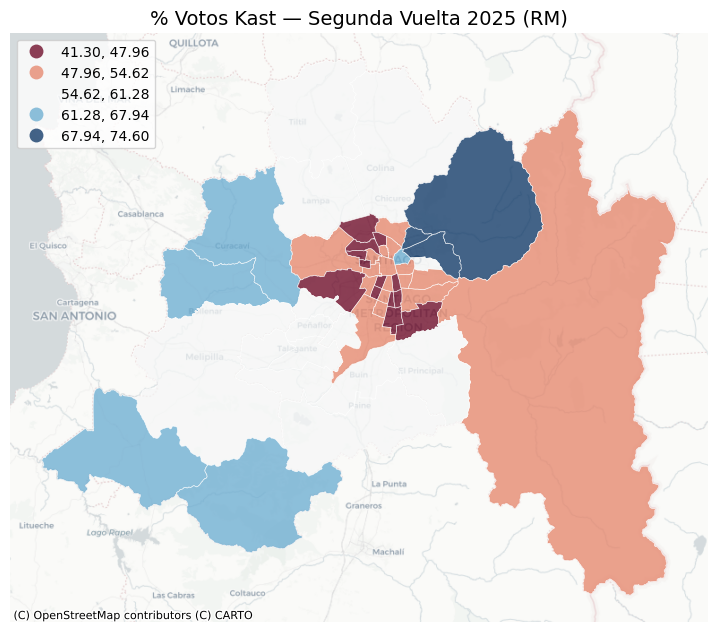

In [5]:
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    column="Pct_Kast",
    cmap="RdBu",
    scheme="EqualInterval",
    k=5,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
contextily.add_basemap(
    ax, crs=db.crs, source=contextily.providers.CartoDB.Positron
)
ax.set_axis_off()
ax.set_title("% Votos Kast — Segunda Vuelta 2025 (RM)", fontsize=14)
plt.show()

El mapa sugiere un patrón espacial: las comunas del sector oriente (Las Condes, Vitacura, Lo Barnechea, Providencia) muestran porcentajes altos de voto por Kast, mientras que comunas del sector sur y poniente (Pedro Aguirre Cerda, Cerro Navia, Lo Espejo) muestran porcentajes bajos. Sin embargo, necesitamos **estadísticos formales** para confirmar si este patrón es significativamente distinto de una distribución aleatoria.

## 2.3 Construcción de la matriz de pesos espaciales

In [6]:
# Matriz de k-vecinos más cercanos (k=8)
w = weights.KNN.from_dataframe(db, k=8)
# Estandarización por filas
w.transform = "R"

# 3. Autocorrelación espacial global

## 3.1 Rezago espacial (*Spatial Lag*)

El **rezago espacial** calcula un promedio ponderado de los valores de las comunas vecinas:

$$y_{sl-i} = \sum_j w_{ij} \cdot y_j$$

Esto nos permite comparar el valor de una comuna con el promedio de su vecindario.

In [7]:
# Calcular el rezago espacial del % Kast
db["Pct_Kast_lag"] = weights.spatial_lag.lag_spatial(w, db["Pct_Kast"])

In [8]:
# Comparar comunas con contextos espaciales contrastantes
comunas_interes = db[db["NOM_COMUNA"].isin(
    ["LAS CONDES", "RECOLETA", "VITACURA", "PEDRO AGUIRRE CERDA"]
)]
comunas_interes[["NOM_COMUNA", "Pct_Kast", "Pct_Kast_lag"]]

,NOM_COMUNA,Pct_Kast,Pct_Kast_lag
14,PEDRO AGUIRRE CERDA,41.3,50.3500
15,RECOLETA,48.8,55.4125
22,LAS CONDES,72.4,55.5750
25,VITACURA,74.6,55.8000


**Las Condes** y **Vitacura**, con alto voto Kast, tienen rezagos espaciales también altos — reflejando que están rodeadas de comunas con preferencias similares. En cambio, **Recoleta** y **Pedro Aguirre Cerda**, con bajo voto Kast, tienen rezagos que reflejan vecindarios igualmente contrarios a Kast.

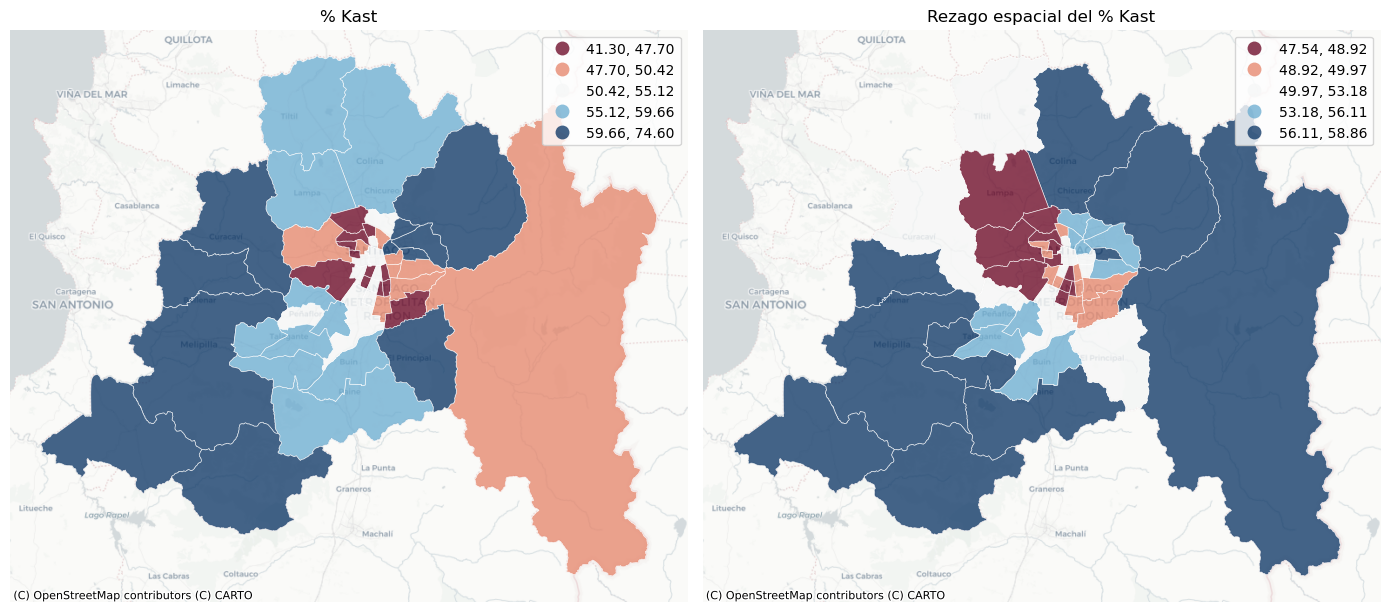

In [9]:
# Mapas lado a lado: valor original vs. rezago espacial
f, axs = plt.subplots(1, 2, figsize=(14, 7))
ax1, ax2 = axs

db.plot(
    column="Pct_Kast",
    cmap="RdBu",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.75,
    legend=True,
    ax=ax1,
)
ax1.set_axis_off()
ax1.set_title("% Kast")
contextily.add_basemap(
    ax1, crs=db.crs, source=contextily.providers.CartoDB.Positron
)

db.plot(
    column="Pct_Kast_lag",
    cmap="RdBu",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.75,
    legend=True,
    ax=ax2,
)
ax2.set_axis_off()
ax2.set_title("Rezago espacial del % Kast")
contextily.add_basemap(
    ax2, crs=db.crs, source=contextily.providers.CartoDB.Positron
)

plt.tight_layout()
plt.show()

El mapa de rezago espacial (derecha) suaviza las diferencias abruptas del mapa original. Las transiciones entre zonas pro-Kast y pro-Jara se atenúan, pero el patrón general se mantiene.

## 3.2 Caso binario: *Join Counts*

Los **Join Counts** evalúan la autocorrelación espacial para variables binarias. Codificamos cada comuna como 1 si Kast obtuvo más del 50% de los votos.

In [10]:
# Crear variable binaria: 1 si Kast > 50%
db["Kast_gana"] = (db["Pct_Kast"] > 50).astype(int)
db[["NOM_COMUNA", "Pct_Kast", "Kast_gana"]].tail()

,NOM_COMUNA,Pct_Kast,Kast_gana
47,SANTIAGO,54.2,1
48,EL MONTE,56.2,1
49,TALAGANTE,55.9,1
50,SAN PEDRO,61.7,1
51,ALHUÉ,62.3,1


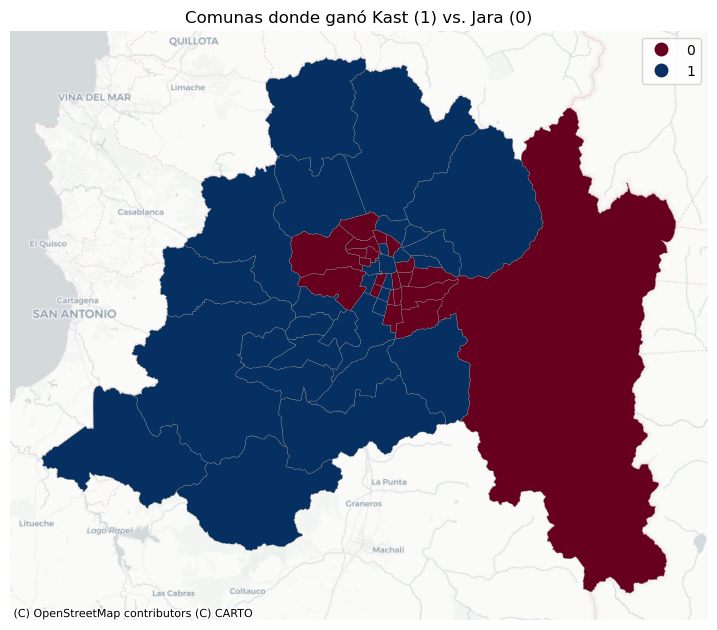

In [11]:
# Mapa de la variable binaria
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    ax=ax,
    column="Kast_gana",
    categorical=True,
    legend=True,
    edgecolor="0.5",
    linewidth=0.25,
    cmap="RdBu",
    figsize=(9, 9),
)
contextily.add_basemap(
    ax, crs=db.crs, source=contextily.providers.CartoDB.Positron
)
ax.set_axis_off()
ax.set_title("Comunas donde ganó Kast (1) vs. Jara (0)")
plt.show()

In [12]:
# Join Counts requiere pesos binarios (no estandarizados)
w.transform = "O"

In [13]:
# Calcular Join Counts
seed(1234)
jc = esda.join_counts.Join_Counts(db["Kast_gana"], w)

In [14]:
# Resultados: conteo de uniones observadas
print(f"Uniones Jara-Jara (0-0): {jc.bb}")
print(f"Uniones Kast-Kast (1-1): {jc.ww}")
print(f"Uniones Jara-Kast (0-1): {jc.bw}")
print(f"Total de uniones: {jc.J}")

Uniones Jara-Jara (0-0): 76.0
Uniones Kast-Kast (1-1): 50.5
Uniones Jara-Kast (0-1): 81.5
Total de uniones: 208.0


In [15]:
# Valores esperados bajo aleatoriedad y pseudo p-valores
print(f"Uniones Jara-Jara esperadas: {jc.mean_bb:.1f}")
print(f"Uniones Jara-Kast esperadas: {jc.mean_bw:.1f}")
print(f"\nP-valor uniones misma categoría: {jc.p_sim_bb:.4f}")
print(f"P-valor uniones distinta categoría: {jc.p_sim_bw:.4f}")

Uniones Jara-Jara esperadas: 72.9
Uniones Jara-Kast esperadas: 102.2

P-valor uniones misma categoría: 0.2730
P-valor uniones distinta categoría: 0.9970


Si los p-valores son significativos, confirman que la distribución espacial del voto no es aleatoria: las comunas pro-Kast tienden a estar junto a otras comunas pro-Kast, y lo mismo para las comunas pro-Jara.

## 3.3 Caso continuo: I de Moran y Gráfico de Moran

El **I de Moran** es el estadístico más utilizado para medir autocorrelación espacial en variables continuas:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij} \, z_i \, z_j}{\sum_i z_i^2}$$

Donde $z_i = y_i - \bar{y}$ es el valor centrado en la media.

In [16]:
# Estandarizar la variable (restar la media)
db["Pct_Kast_std"] = db["Pct_Kast"] - db["Pct_Kast"].mean()

# Calcular el rezago espacial de la variable estandarizada
db["Pct_Kast_lag_std"] = weights.lag_spatial(w, db["Pct_Kast_std"])

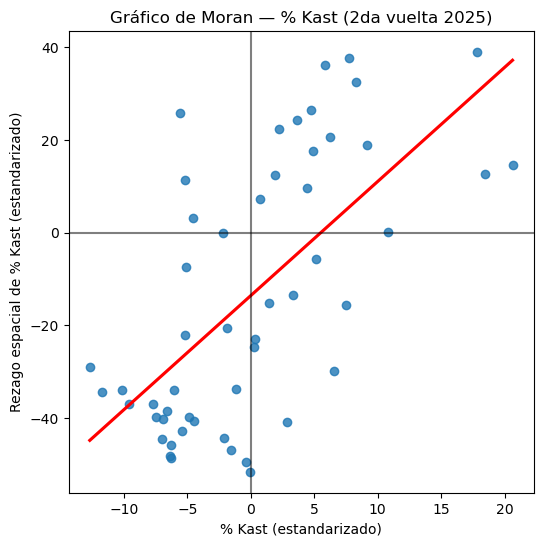

In [17]:
# Gráfico de Moran
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="Pct_Kast_std",
    y="Pct_Kast_lag_std",
    ci=None,
    data=db,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Gráfico de Moran — % Kast (2da vuelta 2025)")
ax.set_xlabel("% Kast (estandarizado)")
ax.set_ylabel("Rezago espacial de % Kast (estandarizado)")
plt.show()

Una pendiente positiva en el gráfico de Moran indica **autocorrelación espacial positiva**: comunas con alto (bajo) voto Kast tienden a estar rodeadas de comunas con alto (bajo) voto Kast.

In [18]:
# Calcular I de Moran formalmente
w.transform = "R"
moran = esda.moran.Moran(db["Pct_Kast"], w)

In [19]:
print(f"I de Moran: {moran.I:.4f}")
print(f"Pseudo p-valor: {moran.p_sim:.4f}")

I de Moran: 0.3078
Pseudo p-valor: 0.0010


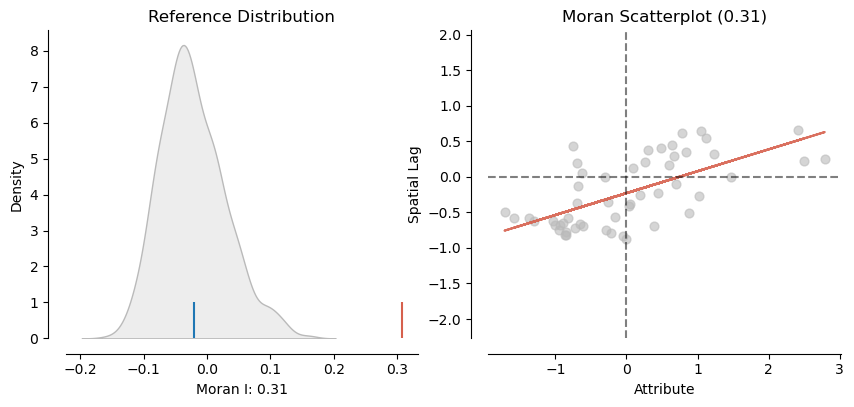

In [20]:
# Visualización combinada con splot
plot_moran(moran);

El panel izquierdo muestra la distribución empírica del I de Moran bajo 999 permutaciones aleatorias. La marca roja indica el valor observado. Si se ubica sustancialmente por encima de la distribución, hay evidencia de autocorrelación espacial positiva significativa.

## 3.4 C de Geary

La **C de Geary** mide la similitud entre vecinos a través de diferencias al cuadrado:

$$C = \frac{(n-1)}{2 \sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij} (y_i - y_j)^2}{\sum_i (y_i - \bar{y})^2}$$

- $C < 1$: autocorrelación positiva
- $C = 1$: aleatoriedad
- $C > 1$: autocorrelación negativa

In [21]:
geary = esda.geary.Geary(db["Pct_Kast"], w)

print(f"C de Geary: {geary.C:.4f}")
print(f"Pseudo p-valor: {geary.p_sim:.4f}")

C de Geary: 0.6180
Pseudo p-valor: 0.0010


Un valor de C significativamente menor que 1 confirma autocorrelación espacial positiva, consistente con los resultados del I de Moran.

## 3.5 G de Getis y Ord

El estadístico **G** mide la concentración de valores altos o bajos:

$$G(d) = \frac{\sum_i \sum_j w_{ij}(d) \, y_i \, y_j}{\sum_i \sum_j y_i \, y_j}$$

In [22]:
# Reproyectar a UTM zona 19S (EPSG:32719) para distancias en metros
db_utm = db.to_crs(epsg=32719)

# Distancia mínima umbral
pts = db_utm.centroid
xys = pandas.DataFrame({"X": pts.x, "Y": pts.y})
min_thr = weights.util.min_threshold_distance(xys)
print(f"Distancia umbral mínima: {min_thr:.1f} metros")

Distancia umbral mínima: 38016.2 metros


In [23]:
# Pesos de banda de distancia
w_db = weights.DistanceBand.from_dataframe(db_utm, min_thr)

/Users/daniela/miniconda3/envs/aves/lib/python3.11/site-packages/libpysal/weights/util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 40.
  w = W(neighbors, weights, ids, **kwargs)
/Users/daniela/miniconda3/envs/aves/lib/python3.11/site-packages/libpysal/weights/distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 40.
  W.__init__(


In [24]:
# G de Getis y Ord
gao = esda.getisord.G(db["Pct_Kast"].values, w_db)

print(f"G de Getis-Ord: {gao.G:.4f}")
print(f"Pseudo p-valor: {gao.p_sim:.4f}")

G de Getis-Ord: 0.6244
Pseudo p-valor: 0.0030


Un p-valor significativo indica que los valores de voto Kast no se distribuyen aleatoriamente en el espacio, sino que muestran patrones de concentración.

# 4. Resumen

| Estadístico | Tipo de variable | Qué mide | Valor de referencia |
|-------------|-----------------|----------|-----------------------|
| Join Counts | Binaria | Agrupación de categorías (Kast/Jara) | Esperado bajo aleatoriedad |
| I de Moran | Continua | Correlación espacial global | $I = 0$ (sin autocorrelación) |
| C de Geary | Continua | Similitud entre vecinos | $C = 1$ (aleatoriedad) |
| G de Getis-Ord | Continua (positiva) | Concentración de valores | Esperado bajo aleatoriedad |

Los resultados permiten evaluar si la distribución espacial del voto en la Región Metropolitana presenta patrones significativos de agrupamiento, o si podría ser producto del azar.

# 5. Preguntas de estudio

1. Repite el análisis completo usando `Pct_Jara` en lugar de `Pct_Kast`:
   - a) ¿Obtienes los mismos resultados de autocorrelación? ¿Por qué?
   - b) Compara los gráficos de Moran de ambas variables.

2. Modifica el número de vecinos en la matriz de pesos (prueba con k=4 y k=12):
   - a) ¿Cómo cambian los valores del I de Moran?
   - b) ¿Los resultados son robustos al cambio de k?

3. Investiga comunas específicas:
   - a) Identifica comunas donde el valor observado y el rezago espacial están en cuadrantes opuestos del gráfico de Moran (outliers espaciales).
   - b) ¿Qué factores podrían explicar estas discrepancias?